Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 13,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. While some factors are intuitively understood (e.g., low grades), the relative importance and interaction of various predictors—such as financial stress (tuition vs. loans), academic preparation (High School Grade vs. University GPA), program characteristics (type, level), and student engagement (attendance, extracurricular participation)—are not clearly defined for this specific population.
Specifically, the dataset allows us to investigate key questions that are currently unanswered:
•What is the primary driver of dropout: pre-university academic preparedness (High School Grade), current academic performance (University GPA), or financial constraints (tuition fees, loan availability)?
•How do financial factors (e.g., Tuition_Fees, Student_Loan amount, Scholarship status) interact with academic factors to influence dropout risk?
•Does the impact of these factors vary significantly by student demographics (e.g., Gender, County), the program of study (Program, Program_Level), or levels of engagement (Attendance_Rate, Extracurricular_Participation)?
•Can a predictive model be built to identify students at high risk of dropping out before it happens, based on their first-year or pre-enrollment data?

3. Data Suitability
The provided dataset is well-structured for addressing this problem. It contains:
•Target Variable: A clear binary outcome variable (Dropout), where 1 indicates a student dropped out and 0 indicates they persisted.
•Predictor Variables: A wide range of potential predictors, including:
•Academic: High_School_Grade, University_GPA
•Financial: Scholarship (binary), Tuition_Fees, Student_Loan
•Demographic: Age, Gender, County
•Institutional: Program (e.g., Law, Engineering), Program_Level (e.g., Undergraduate, Postgraduate)
•Engagement: Attendance_Rate (%), Extracurricular_Participation (binary)
•Family Background: Parental_Education_Level
•Scale & Completeness: With over 13,000 records, the dataset has sufficient statistical power to detect meaningful patterns. However, a preliminary check for missing or inconsistent data is necessary before analysis.

4. Objectives of the Analysis
The primary objective is to identify, quantify, and model the key determinants of student dropout in this Kenyan higher education dataset. Specific sub-objectives include:
1.Descriptive Analysis: To profile the student population and compare the characteristics of those who dropped out versus those who persisted, across all academic, financial, demographic, and engagement variables.
2.Exploratory Factor Analysis: To investigate the relationship between independent variables (e.g., Tuition Fees and Student Loan) and the dependent variable (Dropout), and to explore correlations between predictors (e.g., High_School_Grade and University_GPA).
3.Predictive Modeling: To develop and evaluate a classification model (e.g., Logistic Regression, Random Forest, XGBoost) that can accurately predict a student's risk of dropping out based on available data. Feature importance from this model will reveal the most influential factors.
4.Actionable Insights Generation: To translate the findings from the analysis and model into clear, actionable recommendations for university administrators and policymakers. This includes identifying which student segments are most at risk and suggesting targeted interventions (e.g., financial aid restructuring, academic support programs, or engagement initiatives).

5. Expected Outcomes & Impact
A successful analysis will produce:
•A ranked list of the most significant predictors of student dropout in this context.
•A validated predictive model for early identification of at-risk students.
•Data-driven policy recommendations to reduce dropout rates, improve student retention, and optimize the allocation of institutional resources (e.g., targeting financial aid or tutoring to those who need it most).
Ultimately, this analysis aims to contribute to a more efficient and equitable higher education system in Kenya, ensuring that more students who enroll are able to successfully complete their chosen programs.

In [2]:
# Importing the necessary libraries for the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [5]:
# Loading the dataset
School_df = pd.read_excel("kenyan_student_dropout_data.xlsx")
School_df.head(20)

,Student_ID,Age,Gender,County,High_School_Grade,University_GPA,Program,Program_Level,Scholarship,Tuition_Fees,Student_Loan,Attendance_Rate,Extracurricular_Participation,Parental_Education_Level,Dropout
0,SID00001,23,Male,Nairobi,68.29,2.02,Arts,Postgraduate,0,45892.86,39291.50,56.95,0,Tertiary,0
1,SID00002,18,Female,Kisumu,52.29,3.07,Law,Diploma,1,28021.47,27395.74,76.89,1,Primary,1
2,SID00003,21,Male,Kakamega,63.55,2.34,Science,Diploma,0,41142.06,19269.70,68.47,1,None,1
3,SID00004,29,Male,Kisumu,82.64,2.19,Education,Undergraduate,0,58743.46,18217.61,52.40,1,Primary,0
4,SID00005,21,Male,Kakamega,73.93,2.97,Arts,Diploma,1,49471.32,35845.25,88.59,1,None,1
5,SID00006,25,Female,Nakuru,69.90,2.83,Education,Postgraduate,1,53671.29,24761.46,88.10,1,Primary,0
6,SID00007,27,Male,Kakamega,55.06,1.44,Business,Postgraduate,0,63912.45,37299.60,66.04,1,Primary,0
7,SID00008,21,Female,Nairobi,74.83,2.07,Education,Diploma,0,53283.59,28651.81,51.18,0,Tertiary,0
8,SID00009,23,Male,Nakuru,66.88,3.40,Business,Undergraduate,0,63955.79,30635.94,77.88,0,Tertiary,0
9,SID00010,20,Female,Kakamega,73.00,3.14,Education,Undergraduate,1,23477.32,19718.86,57.76,1,Primary,0


In [7]:
# Showing the general layout of our dataset

School_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13465 entries, 0 to 13464
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_ID                     13465 non-null  object 
 1   Age                            13465 non-null  int64  
 2   Gender                         13465 non-null  object 
 3   County                         13465 non-null  object 
 4   High_School_Grade              13465 non-null  float64
 5   University_GPA                 13465 non-null  float64
 6   Program                        13465 non-null  object 
 7   Program_Level                  13465 non-null  object 
 8   Scholarship                    13465 non-null  int64  
 9   Tuition_Fees                   13465 non-null  float64
 10  Student_Loan                   13465 non-null  float64
 11  Attendance_Rate                13465 non-null  float64
 12  Extracurricular_Participation  13465 non-null 

In [10]:
# checking for null values in our dataset

School_df.isna().sum()

Student_ID                       0
Age                              0
Gender                           0
County                           0
High_School_Grade                0
University_GPA                   0
Program                          0
Program_Level                    0
Scholarship                      0
Tuition_Fees                     0
Student_Loan                     0
Attendance_Rate                  0
Extracurricular_Participation    0
Parental_Education_Level         0
Dropout                          0
dtype: int64

In [9]:
# Checking the Statistical distribution

School_df.describe()

,Age,High_School_Grade,University_GPA,Scholarship,Tuition_Fees,Student_Loan,Attendance_Rate,Extracurricular_Participation,Dropout
count,13465.000000,13465.000000,13465.000000,13465.000000,13465.000000,13465.000000,13465.000000,13465.000000,13465.000000
mean,23.539844,64.959696,2.501246,0.300483,50095.535244,29893.798468,75.230356,0.404679,0.150093
std,3.458038,10.000970,0.499105,0.458485,9995.899493,8045.796356,14.388901,0.490848,0.357176
min,18.000000,18.400000,0.500000,0.000000,6663.050000,-3208.930000,50.000000,0.000000,0.000000
25%,21.000000,58.290000,2.170000,0.000000,43400.950000,24514.420000,62.870000,0.000000,0.000000
50%,24.000000,65.040000,2.510000,0.000000,50142.240000,29893.820000,75.250000,0.000000,0.000000
75%,27.000000,71.610000,2.840000,1.000000,56808.390000,35238.620000,87.690000,1.000000,0.000000
max,29.000000,103.320000,4.400000,1.000000,89753.890000,59949.520000,100.000000,1.000000,1.000000


In [ ]:
# Visualizing the age distribution
School_df['Age'].value_counts()

26    1165
27    1164
19    1155
29    1150
23    1147
21    1128
28    1119
24    1092
20    1091
25    1090
18    1084
22    1080
Name: Age, dtype: int64

In [14]:
# creating age group bins

bins = [18, 21, 24, 27, 30]
labels = ['18-20', '21-23', '24-26', '27-29']

School_df['Age_Group'] = pd.cut(School_df['Age'], bins=bins, labels=labels, right=False)

In [15]:
School_df.head()

,Student_ID,Age,Gender,County,High_School_Grade,University_GPA,Program,Program_Level,Scholarship,Tuition_Fees,Student_Loan,Attendance_Rate,Extracurricular_Participation,Parental_Education_Level,Dropout,Age_Group
0,SID00001,23,Male,Nairobi,68.29,2.02,Arts,Postgraduate,0,45892.86,39291.50,56.95,0,Tertiary,0,21-23
1,SID00002,18,Female,Kisumu,52.29,3.07,Law,Diploma,1,28021.47,27395.74,76.89,1,Primary,1,18-20
2,SID00003,21,Male,Kakamega,63.55,2.34,Science,Diploma,0,41142.06,19269.70,68.47,1,None,1,21-23
3,SID00004,29,Male,Kisumu,82.64,2.19,Education,Undergraduate,0,58743.46,18217.61,52.40,1,Primary,0,27-29
4,SID00005,21,Male,Kakamega,73.93,2.97,Arts,Diploma,1,49471.32,35845.25,88.59,1,None,1,21-23


In [43]:
School_df['Dropout'].value_counts()

0    11444
1     2021
Name: Dropout, dtype: int64

Age_Group         18-20     21-23     24-26     27-29
Program_Level                                        
Diploma        0.165605  0.160791  0.131278  0.143750
Postgraduate   0.150772  0.154399  0.158470  0.153169
Undergraduate  0.146903  0.158627  0.135548  0.142736


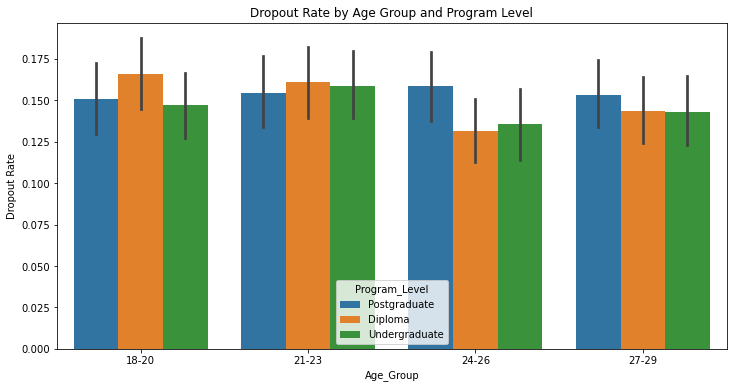

In [27]:
pivot = School_df.pivot_table(
    values='Dropout',
    index='Program_Level',
    columns='Age_Group',
    #aggfunc='mean'
)

print(pivot)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Age_Group',
    y='Dropout',
    hue='Program_Level',
    data=School_df
)
plt.title('Dropout Rate by Age Group and Program Level')
plt.ylabel('Dropout Rate')
plt.show()

Program_Level   Diploma  Postgraduate  Undergraduate
Program                                             
Arts           0.146801      0.140865       0.160000
Business       0.153747      0.149746       0.132682
Education      0.151811      0.158254       0.160995
Engineering    0.144754      0.176718       0.147020
Law            0.164021      0.151436       0.140940
Science        0.140473      0.148907       0.131720


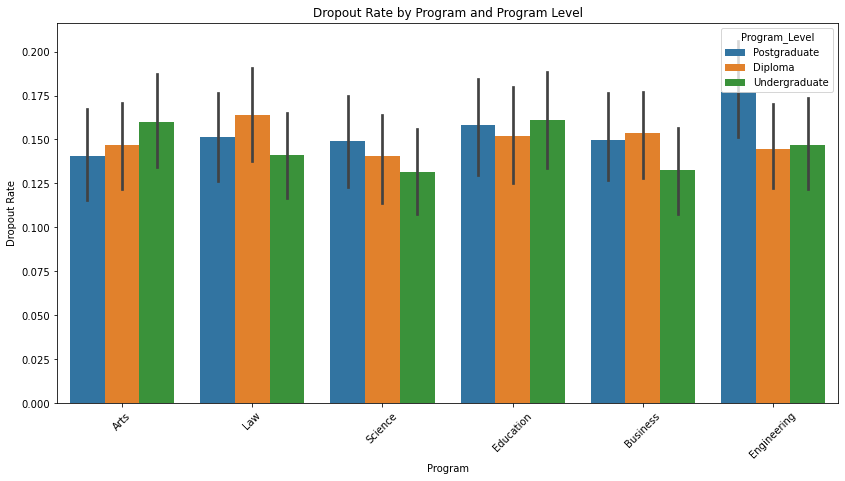

In [29]:
pivot = School_df.pivot_table(
    values='Dropout',
    index='Program',
    columns='Program_Level',
    aggfunc='mean'
)

print(pivot)
plt.figure(figsize=(14, 7))

sns.barplot(
    x='Program',
    y='Dropout',
    hue='Program_Level',
    data=School_df
)

plt.xticks(rotation=45)
plt.title('Dropout Rate by Program and Program Level')
plt.ylabel('Dropout Rate')
plt.show()

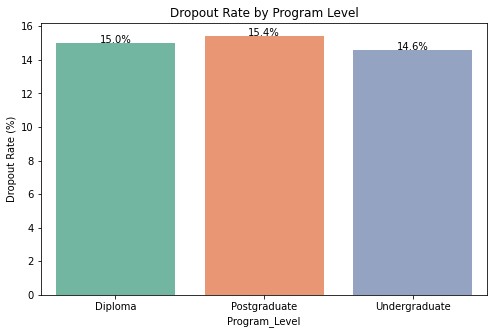

In [35]:
dropout_rate = School_df.groupby('Program_Level')['Dropout'].mean().reset_index()
dropout_rate['Dropout'] = dropout_rate['Dropout'] * 100  # convert to percentage

plt.figure(figsize=(8, 5))
barplot = sns.barplot(
    x='Program_Level',
    y='Dropout',
    data=dropout_rate,
    palette='Set2'
)
plt.title('Dropout Rate by Program Level')
plt.ylabel('Dropout Rate (%)')

# Annotate each bar with the percentage
for p in barplot.patches:
    height = p.get_height()
    barplot.text(
        x=p.get_x() + p.get_width() / 2,  # center of the bar
        y=height,                     # slightly above the bar
        s=f'{height:.1f}%',               # formatted percentage
        ha='center'
    )

plt.show()

     County    Dropout
0   Eldoret  14.717859
1   Garissa  14.199759
2  Kakamega  16.364734
3    Kisumu  14.742451
4      Meru  14.178241
5   Mombasa  15.291262
6   Nairobi  15.700483
7    Nakuru  14.938489


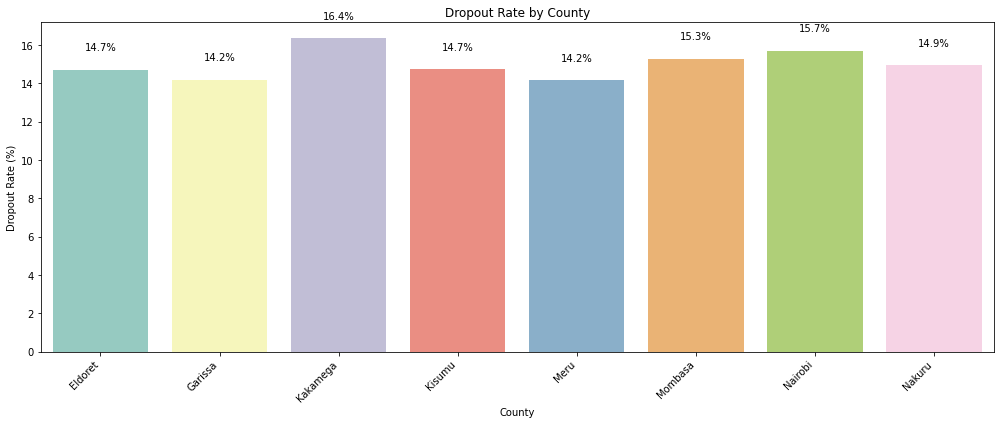

In [36]:
# Calculate dropout rate per county
dropout_by_county = School_df.groupby('County')['Dropout'].mean().reset_index()

# Convert to percentage
dropout_by_county['Dropout'] = dropout_by_county['Dropout'] * 100

# Inspect
print(dropout_by_county)

plt.figure(figsize=(14, 6))
sns.barplot(
    x='County',
    y='Dropout',
    data=dropout_by_county,
    palette='Set3'
)
plt.xticks(rotation=45, ha='right')
plt.title('Dropout Rate by County')
plt.ylabel('Dropout Rate (%)')

# Annotate bars with percentage
for p in plt.gca().patches:
    plt.gca().text(
        x=p.get_x() + p.get_width() / 2,
        y=p.get_height() + 1,
        s=f'{p.get_height():.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

   Scholarship    Dropout
0            0  15.044060
1            1  14.928324


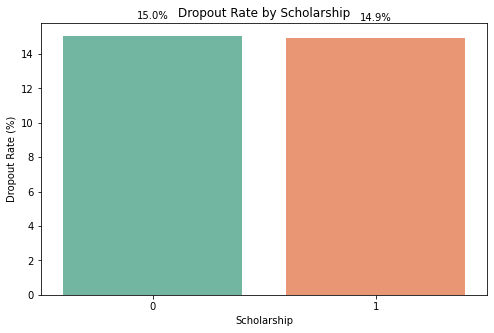

In [37]:
# Calculate dropout rate per scholarship category
dropout_by_scholarship = School_df.groupby('Scholarship')['Dropout'].mean().reset_index()

# Convert to percentage
dropout_by_scholarship['Dropout'] = dropout_by_scholarship['Dropout'] * 100

# Inspect
print(dropout_by_scholarship)

plt.figure(figsize=(8, 5))
barplot = sns.barplot(
    x='Scholarship',
    y='Dropout',
    data=dropout_by_scholarship,
    palette='Set2'
)
plt.title('Dropout Rate by Scholarship')
plt.ylabel('Dropout Rate (%)')

# Annotate bars with percentage
for p in barplot.patches:
    height = p.get_height()
    barplot.text(
        x=p.get_x() + p.get_width()/2,
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center'
    )

plt.show()

   Gender    Dropout
0  Female  15.045844
1    Male  14.973576


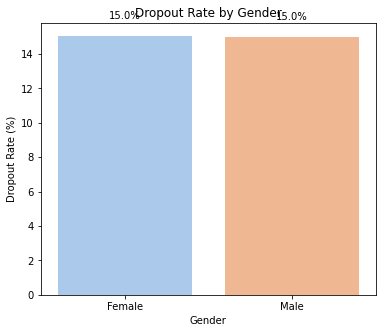

In [38]:
# Calculate dropout rate per gender
dropout_by_gender = School_df.groupby('Gender')['Dropout'].mean().reset_index()

# Convert to percentage
dropout_by_gender['Dropout'] = dropout_by_gender['Dropout'] * 100

# Inspect
print(dropout_by_gender)

plt.figure(figsize=(6, 5))
barplot = sns.barplot(
    x='Gender',
    y='Dropout',
    data=dropout_by_gender,
    palette='pastel'
)
plt.title('Dropout Rate by Gender')
plt.ylabel('Dropout Rate (%)')

# Annotate bars with percentage
for p in barplot.patches:
    height = p.get_height()
    barplot.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center'
    )

plt.show()

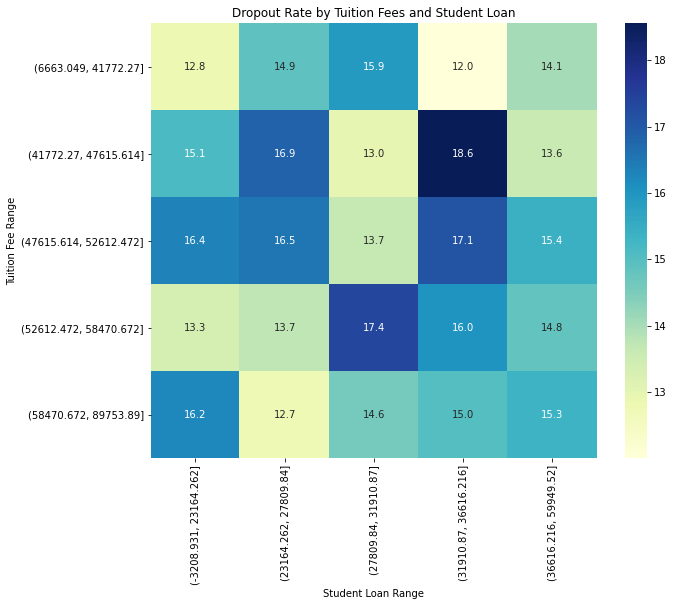

In [40]:
loan_bins = pd.qcut(School_df['Student_Loan'], q=5)
tuition_bins = pd.qcut(School_df['Tuition_Fees'], q=5)

pivot = School_df.pivot_table(
    values='Dropout',
    index=tuition_bins,
    columns=loan_bins,
    aggfunc='mean'
) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Dropout Rate by Tuition Fees and Student Loan")
plt.ylabel("Tuition Fee Range")
plt.xlabel("Student Loan Range")
plt.show()

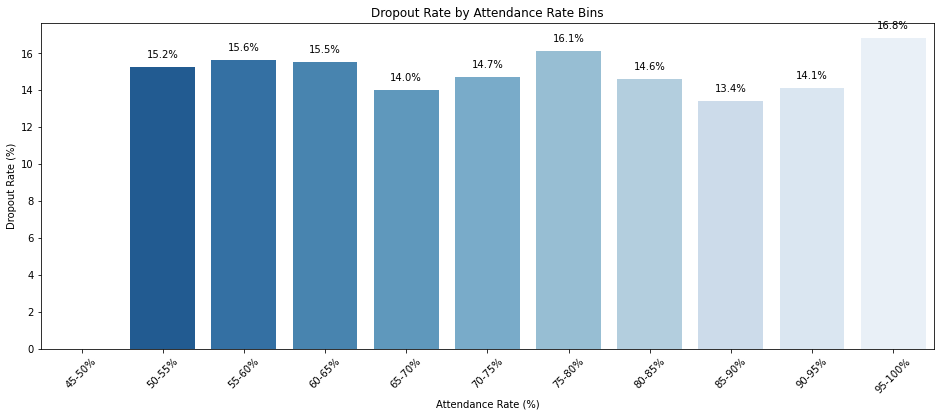

In [42]:
# --- Step 1: Create attendance rate bins ---
bins = list(range(45, 105, 5))  # 0,5,10,...,100
labels = [f"{i}-{i+5}%" for i in bins[:-1]]
School_df['Attendance_Bin'] = pd.cut(School_df['Attendance_Rate'], bins=bins, labels=labels, right=False)

# --- Step 2: Calculate dropout rate per bin ---
dropout_by_attendance = School_df.groupby('Attendance_Bin')['Dropout'].mean().reset_index()
dropout_by_attendance['Dropout'] = dropout_by_attendance['Dropout'] * 100  # percentage

# --- Step 3: Plot bar chart with annotations ---
plt.figure(figsize=(16, 6))
barplot = sns.barplot(
    x='Attendance_Bin',
    y='Dropout',
    data=dropout_by_attendance,
    palette='Blues_r'
)
plt.title('Dropout Rate by Attendance Rate Bins')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=45)

# Annotate bars with dropout percentages
for p in barplot.patches:
    height = p.get_height()
    barplot.text(
        x=p.get_x() + p.get_width()/2,
        y=height + 0.5,
        s=f'{height:.1f}%',
        ha='center'
    )

plt.show()